**Generative Adverserial Network (GAN)** 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.utils import plot_model

simple function we want to emulate

In [2]:
def func(x):
    from math import sin
    return (x**2*np.sin(3*x)/(x**2+2))

In [3]:
x = np.linspace(-1,1,100)

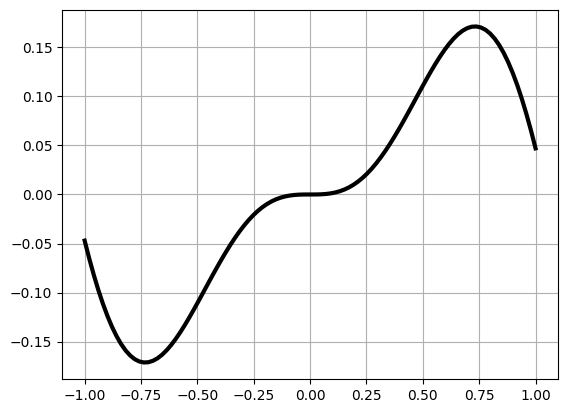

In [4]:
plt.plot(x,func(x), color='k', lw=3)
plt.grid(True)
plt.show()

The Discriminator

define the discriminator model

In [5]:
def define_discriminator(n_inputs=2):
    model = Sequential()
    model.add(Dense(100, activation='relu', kernel_initializer='he_uniform', input_dim=n_inputs))
    model.add(Dense(1, activation='sigmoid'))
    #compile model
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics =['accuracy'])
    return model

In [6]:
#%pip install pydot

In [7]:
# define the discriminator model
model_discriminator =define_discriminator()
#summarize the model
model_discriminator.summary()
#plot the model 
plot_model(model_discriminator, to_file="discriminator_plot.png", show_shapes=True, show_layer_names=True)

C:\Users\oyelola Ibrahim\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


Generate real samples

In [8]:
def generate_real_samples(n, l=-1, h=1):
    #generate inputs in [-l,h]
    X1 = l + (h-l)*np.random.random(size=n)
    #generate outputs X2
    X2 = func(X1)
    #stack arrays 
    X1 = X1.reshape(n,1)
    X2 = X2.reshape(n,1)
    X = np.hstack((X1, X2))
    #generate class labels
    y = np.ones((n,1))
    return X, y

In [9]:
generate_real_samples(5)

(array([[ 0.6991592 ,  0.16979035],
        [-0.78884044, -0.16605599],
        [ 0.29000061,  0.03084325],
        [ 0.89438314,  0.12643471],
        [-0.43650355, -0.08402892]]),
 array([[1.],
        [1.],
        [1.],
        [1.],
        [1.]]))

Generate fake samples

In [10]:
def generate_fake_samples(n, l=-1, h=1):
    #generate inputs in [-l,h]
    X1 = l + (h-l)*np.random.random(size=n)
    #generate outputs X2
    X2 = l + (h-l)*np.random.random(size=n)
    #stack arrays 
    X1 = X1.reshape(n,1)
    X2 = X2.reshape(n,1)
    X = np.hstack((X1, X2))
    #generate class labels
    y = np.zeros((n,1))
    return X, y

In [11]:
generate_fake_samples(5)

(array([[-0.14363593, -0.44486381],
        [-0.83052954, -0.61991959],
        [-0.13525684, -0.4032731 ],
        [ 0.39102572, -0.97589662],
        [ 0.60787595, -0.56986792]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]))

Function to train the discriminator

In [12]:
def train_discriminator(model, n_epochs=1000, n_batch=128):
    half_batch = int(n_batch /2)
    # run epochs manually
    for i in range(n_epochs):
        #generate real examples
        X_real, y_real = generate_real_samples(half_batch)
        # update model
        model.train_on_batch(X_real, y_real)
        #generate fake examples
        X_fake, y_fake = generate_fake_samples(half_batch)
        # update model
        model.train_on_batch(X_fake, y_fake)
        #evaluate the model
        _, acc_real = model.evaluate(X_real, y_real, verbose=0)
        _, acc_fake = model.evaluate(X_fake, y_fake, verbose=0)
        print(i, acc_real, acc_fake)

In [13]:
train_discriminator(model_discriminator, n_epochs=20)

0 0.5625 0.546875
1 0.484375 0.65625
2 0.625 0.46875
3 0.4375 0.421875
4 0.46875 0.578125
5 0.578125 0.5
6 0.390625 0.640625
7 0.53125 0.546875
8 0.546875 0.671875
9 0.5 0.65625
10 0.4375 0.671875
11 0.515625 0.734375
12 0.515625 0.796875
13 0.5 0.828125
14 0.515625 0.78125
15 0.578125 0.84375
16 0.515625 0.828125
17 0.515625 0.78125
18 0.5625 0.859375
19 0.515625 0.890625


In [14]:
x_t, y_t = generate_fake_samples(5)
model_discriminator.evaluate(x_t, y_t)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 1.0000 - loss: 0.5464


[0.5463768243789673, 1.0]

The Generator

In [20]:
#define the standalone generator model
def define_generator(latent_dim, n_outputs=2):
    model = Sequential()
    model.add(Dense(50, activation="relu", kernel_initializer="he_uniform", input_dim = latent_dim))
    model.add(Dense(n_outputs, activation='linear'))
    return model

In [21]:
#define the discriminator model
model_gen = define_generator(5)
#summarize the model
model_gen.summary()
plot_model(model_gen, to_file="discriminator_plot.png", show_shapes=True, show_layer_names=True)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 50)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402 (1.57 KB)

 Trainable params: 402 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


Testing the Generator model

In [24]:
#generate points in latent space as input for the generator
def generate_latent_points(latent_dim, n, l=-1, h=1):
    #generate points in the latent space
    x_input = 1+(h-1)*np.random.random(size= latent_dim*n)
    #reshape into a batch of inputs for the network
    x_input = x_input.reshape(n, latent_dim)
    return x_input

In [27]:
def generate_fake_samples(generator, latent_dim, n):
    #generate points in the latent space
    x_input = generate_latent_points(latent_dim, n)
    # predicts outputs
    X= generator.predict(x_input)
    #plot the results
    plt.scatter(X[:,0], X[:,1], color='k', s=15)
    plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


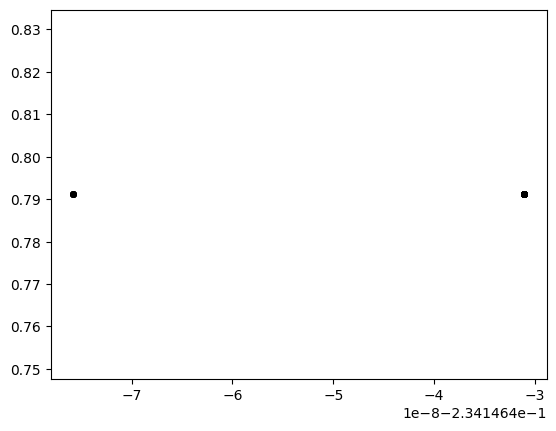

In [28]:
#size of the latent space
latent_dim = 5
#define the discriminator model
model_gen = define_generator(latent_dim)
#generate and plot generated samples
generate_fake_samples(model_gen, latent_dim,100) 

Training the generator model

In [29]:
def generate_fake_samples(generator, latent_dim, n):
    #generate points in the latent space
    x_input = generate_latent_points(latent_dim, n)
    # predicts outputs
    X= generator.predict(x_input)
    # create class labels
    y = np.zeros((n, 1))
    return X, y

In [31]:
# define the combined generator and discriminator model, for updating the generator
def full_gan(generator, discriminator):
    #make weights in the discriminator not trainable
    discriminator.trainable = False
    #connect them 
    model = Sequential()
    # add generator 
    model.add(generator)
    # add the discriminator
    model.add(discriminator)
    # compile model
    model.compile(loss ="binary_crossentropy", optimizer="adam")
    return model

In [35]:
# size of the latent space
latent_dim = 5
# create the discriminator
discriminator = define_discriminator()
#create the generator
generator = define_generator(latent_dim)
#create the gan
model_gan = full_gan(generator, discriminator)
# summarize the model
model_gan.summary()
plot_model(model_gan, to_file="gan_plot.png", show_shapes=True, show_layer_names=True)

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_17 (Sequential)      │ (None, 2)              │           402 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_16 (Sequential)      │ (None, 1)              │           401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803 (3.14 KB)

 Trainable params: 402 (1.57 KB)

 Non-trainable params: 401 (1.57 KB)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


Evaluating performance

In [36]:
def summarize_performance (epoch, generator, discriminator, latent_dim, n=500):
    #prepare real samples 
    x_real, y_real = generate_real_samples(n)
    #evaluate discriminator on real examples
    _, acc_real = discriminator.evaluate(x_real, y_real, verbose=0)
    #prepare fake examples
    x_fake, y_fake = generate_fake_samples(generator, latent_dim, n)
    #evaluate discriminator on fake examples
    _, acc_fake = discriminator.evaluate(x_fake, y_fake, verbose=0)
    # summarize discriminator performance
    print("Data comparism after {} epochs".format(epoch +1))
    print()
    print("Accuracy for the real data: {}, Accuracy for the fake data: {}".format(acc_real, acc_fake))
    print()
    plt.scatter(x_real[:, 0], x_real[:, 1], color='red')
    plt.scatter(x_fake[:, 0], x_fake[:, 1], color='red')
    plt.show()
    print()

Add the summrize_performance function to the train function

In [37]:
# train the generator and discriminator
def train(g_model, d_model, gan_model, latent_dim, n_epochs=10000, n_batch=256, n_eval=1000):
    # determine half the size of one batch, for updating the discriminator
    half_batch = int(n_batch / 2)
    
    # manually enumerate epochs
    for i in range(n_epochs):
        # prepare real samples
        x_real, y_real = generate_real_samples(half_batch)
        # prepare fake examples
        x_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)        
        # update discriminator
        d_model.train_on_batch(x_real, y_real)
        d_model.train_on_batch(x_fake, y_fake)
        # prepare points in latent space as input for the generator
        x_gan = generate_latent_points(latent_dim, n_batch)
        
        # create inverted labels for the fake samples
        y_gan = np.ones((n_batch, 1))
        # update the generator via the discriminator's error
        gan_model.train_on_batch(x_gan, y_gan)
        
        # evaluate the model every n_eval epochs
        if (i + 1) % n_eval == 0:
            summarize_performance(i, g_model, d_model, latent_dim)

In [38]:
# size of the latent space
latent_dim = 5
# create the discriminator
discriminator = define_discriminator()
# create the generator
generator = define_generator(latent_dim)
# create the gan
model_gan = full_gan(generator, discriminator)

C:\Users\oyelola Ibrahim\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


showing performance of the generator before full training

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


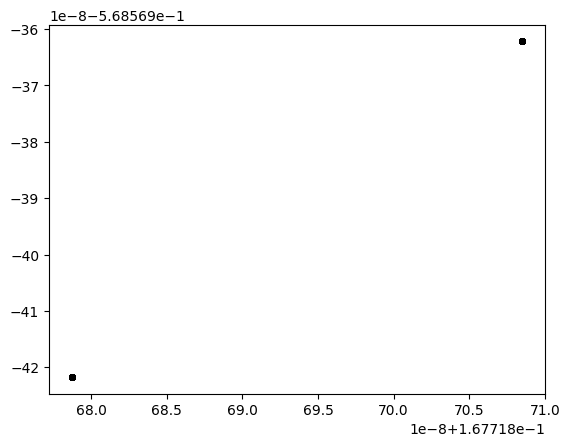

In [40]:
n = 500
x, _ = generate_fake_samples(generator, latent_dim, n)
plt.scatter(x[:,0], x[:,1], color='k', s=15)
plt.show()

actual training of the GAN model

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


C:\Users\oyelola Ibrahim\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━

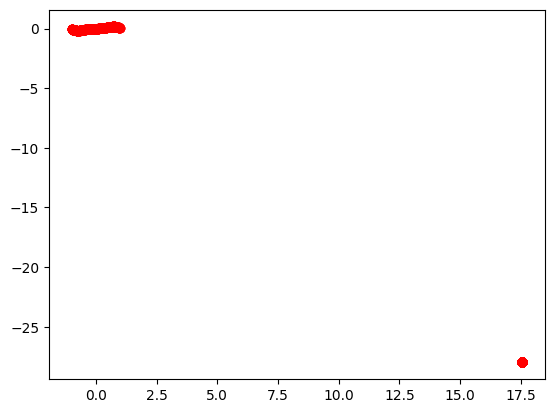


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━

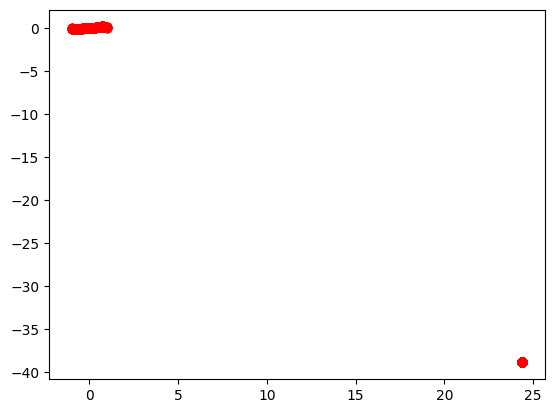


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━

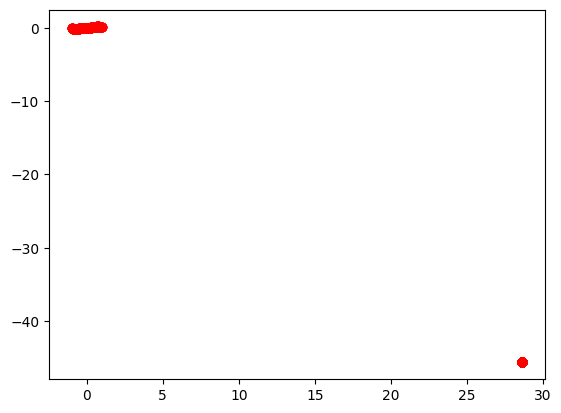


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 

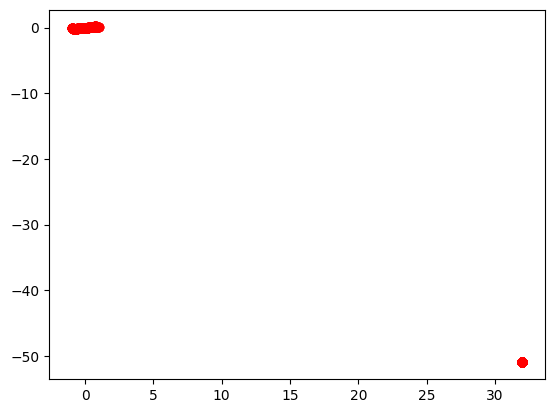


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0

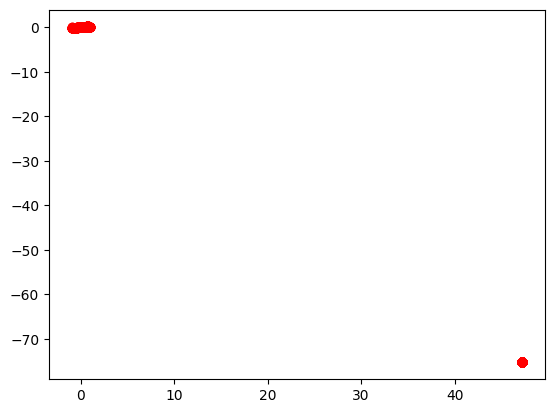

In [41]:
# train model
train (generator, discriminator, model_gan, latent_dim)

Generate synthetic data now

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


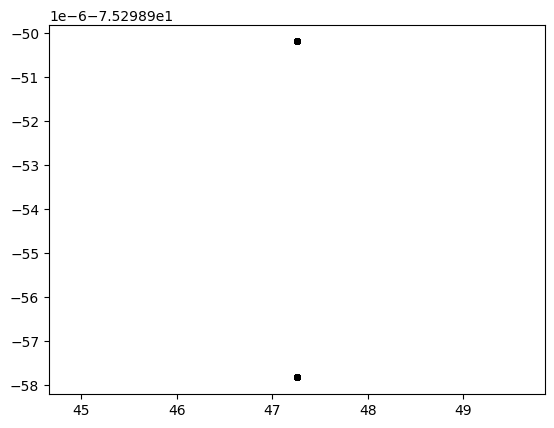

In [43]:
latent_dim = 5
n = 200
x, _ = generate_fake_samples(generator, latent_dim, n)
plt.scatter(x[:,0], x[:,1], color='k', s=15)
plt.show()